In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("Everything is installed!")

Everything is installed!


In [2]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

In [3]:
df = pd.read_csv("dataset/customer_segmentation.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.dropna(inplace = True)

In [5]:
df.isna().sum().sum()

np.int64(0)

In [6]:
df.describe()


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [7]:
df["Education"].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [8]:
df["Marital_Status"].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [9]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst = True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [11]:
df["Age"] = 2025 - df["Year_Birth"]

In [12]:
df["Age"]

0       68
1       71
2       60
3       41
4       44
        ..
2235    58
2236    79
2237    44
2238    69
2239    71
Name: Age, Length: 2216, dtype: int64

In [13]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,68
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,71
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,3,11,0,60
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,3,11,0,41
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,3,11,0,44


In [14]:
df["TotalChildren"] = df["Kidhome"] + df["Teenhome"]

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [16]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'TotalChildren'],
      dtype='object')

In [17]:
spend_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

In [18]:
df["TotalSpendings"] = df[spend_cols].sum(axis = 1)

In [19]:
df["TotalSpendings"]

0       1617
1         27
2        776
3         53
4        422
        ... 
2235    1341
2236     444
2237    1241
2238     843
2239     172
Name: TotalSpendings, Length: 2216, dtype: int64

In [20]:
df["CustomerSince"] = (pd.Timestamp("today") - df["Dt_Customer"]).dt.days

In [21]:
df["CustomerSince"]

0       5072
1       4522
2       4721
3       4548
4       4570
        ... 
2235    4790
2236    4428
2237    4564
2238    4565
2239    5031
Name: CustomerSince, Length: 2216, dtype: int64

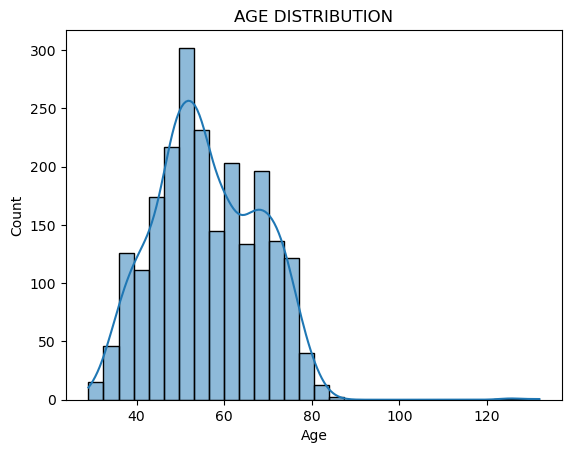

In [22]:
sns.histplot(df["Age"], bins = 30, kde = True)
plt.title("AGE DISTRIBUTION")
plt.show()

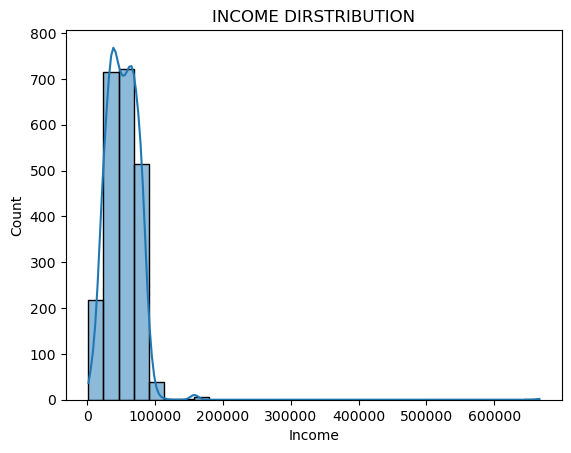

In [23]:
sns.histplot(df["Income"],bins = 30, kde = True)
plt.title("INCOME DIRSTRIBUTION")
plt.show()

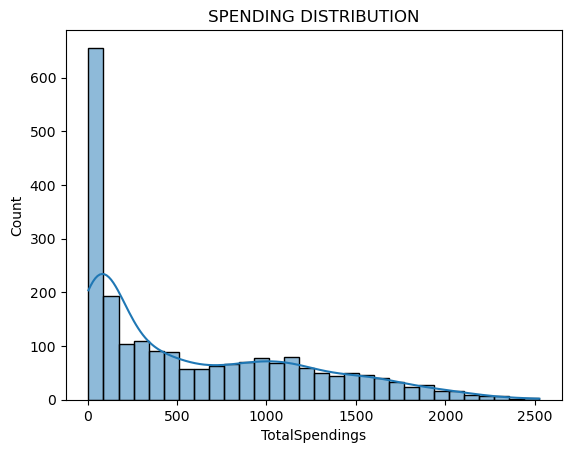

In [24]:
sns.histplot(df["TotalSpendings"], bins = 30, kde = True)
plt.title("SPENDING DISTRIBUTION")
plt.show()

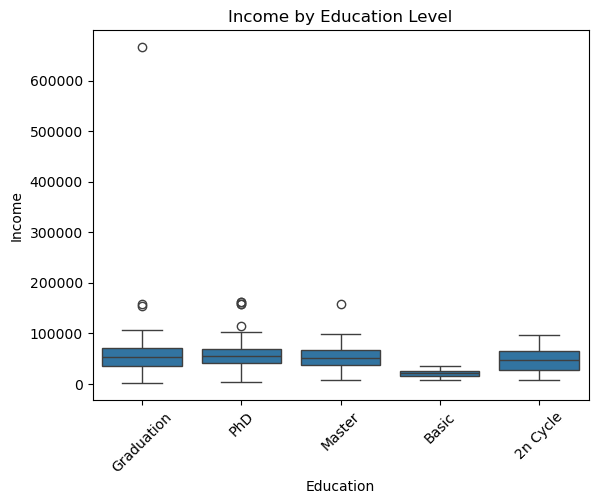

In [25]:
sns.boxplot(x = "Education", y = "Income" , data = df)
plt.xticks(rotation = 45)
plt.title("Income by Education Level")
plt.show()

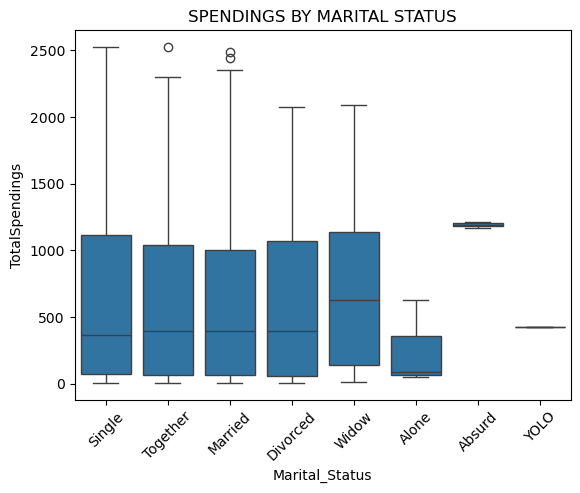

In [26]:
sns.boxplot(x = "Marital_Status", y = "TotalSpendings", data = df)
plt.xticks(rotation = 45)
plt.title("SPENDINGS BY MARITAL STATUS")
plt.show()

In [27]:
corr = df[["Income", "Age", "Recency", "TotalSpendings", "NumWebPurchases", "NumStorePurchases"]].corr()

In [28]:
corr

,Income,Age,Recency,TotalSpendings,NumWebPurchases,NumStorePurchases
Income,1.000000,0.161791,-0.003970,0.667576,0.387878,0.529362
Age,0.161791,1.000000,0.016295,0.113487,0.153051,0.127891
Recency,-0.003970,0.016295,1.000000,0.020066,-0.005641,-0.000434
TotalSpendings,0.667576,0.113487,0.020066,1.000000,0.528973,0.675181
NumWebPurchases,0.387878,0.153051,-0.005641,0.528973,1.000000,0.516240
NumStorePurchases,0.529362,0.127891,-0.000434,0.675181,0.516240,1.000000


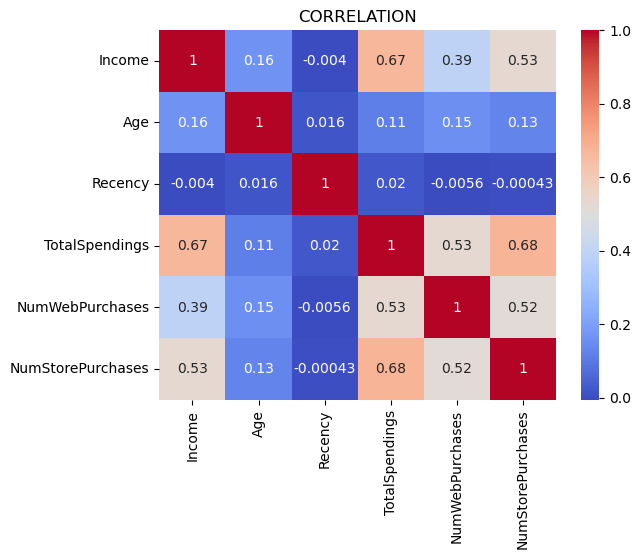

In [29]:
sns.heatmap(corr, annot = True, cmap = "coolwarm")
plt.title("CORRELATION")
plt.show()


In [30]:
pivot_income = df.pivot_table(values = "Income", index = "Education", columns = "Marital_Status", aggfunc = "mean")

In [31]:
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


Text(0.5, 1.0, 'Average Income by Education and Marital Status')

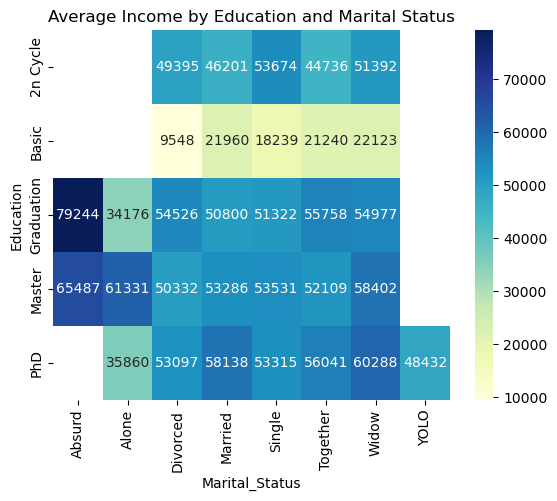

In [32]:
sns.heatmap(pivot_income, annot = True, fmt = ".0f", cmap = "YlGnBu")
plt.title("Average Income by Education and Marital Status")

In [33]:
group1 = df.groupby("Education")["TotalSpendings"].mean().sort_values(ascending = False)

In [34]:
group1

Education
PhD           676.733888
Graduation    621.686380
Master        609.767123
2n Cycle      494.930000
Basic          81.796296
Name: TotalSpendings, dtype: float64

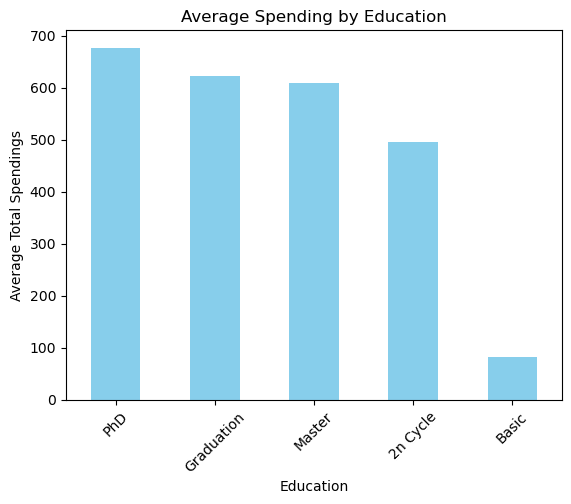

In [35]:
group1.plot(kind = "bar", color = "skyblue")
plt.title("Average Spending by Education")
plt.ylabel("Average Total Spendings")
plt.xticks(rotation = 45)
plt.show()

In [36]:
df["AcceptedAny"] = df[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"]].sum(axis = 1)

In [37]:
df["AcceptedAny"].unique()

array([1, 0, 3, 2, 4, 5])

In [38]:
df["AcceptedAny"]= df["AcceptedAny"].apply(lambda x : 1 if x > 0 else 0 )

In [39]:
df["AcceptedAny"].unique()

array([1, 0])

In [40]:
group2 = df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending = False)

In [41]:
group2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.342105
Alone       0.333333
Single      0.312102
Divorced    0.297414
Married     0.252042
Together    0.251309
Name: AcceptedAny, dtype: float64

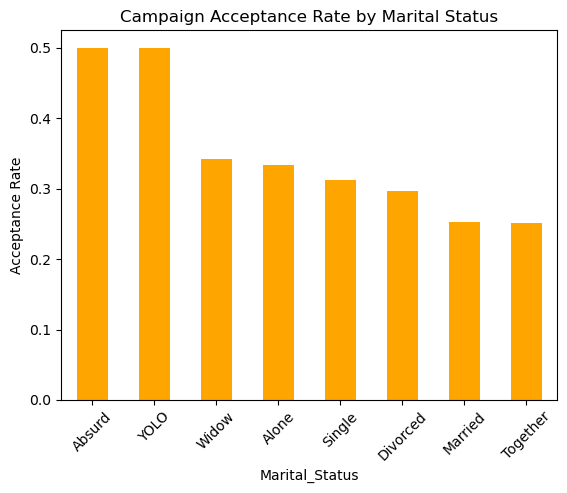

In [42]:
group2.plot(kind = "bar", color = "orange")
plt.title("Campaign Acceptance Rate by Marital Status")
plt.ylabel("Acceptance Rate")
plt.xticks(rotation = 45)
plt.show()


In [43]:
bins = [18, 30, 40, 50, 60, 70, 90]

In [44]:
labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]

In [45]:
df["AgeGroup"] = pd.cut(df["Age"], bins = bins, labels = labels)

In [46]:
df["AgeGroup"]

0       60-69
1         70+
2       50-59
3       40-49
4       40-49
        ...  
2235    50-59
2236      70+
2237    40-49
2238    60-69
2239      70+
Name: AgeGroup, Length: 2216, dtype: category
Categories (6, object): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

In [47]:
group3 = df.groupby("AgeGroup")["Income"].mean()

C:\Users\Hp\AppData\Local\Temp\ipykernel_22040\1140876350.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group3 = df.groupby("AgeGroup")["Income"].mean()


In [48]:
group3

AgeGroup
18-29    46658.000000
30-39    46283.028302
40-49    49224.877034
50-59    50812.913303
60-69    56200.827887
70+      58944.316294
Name: Income, dtype: float64

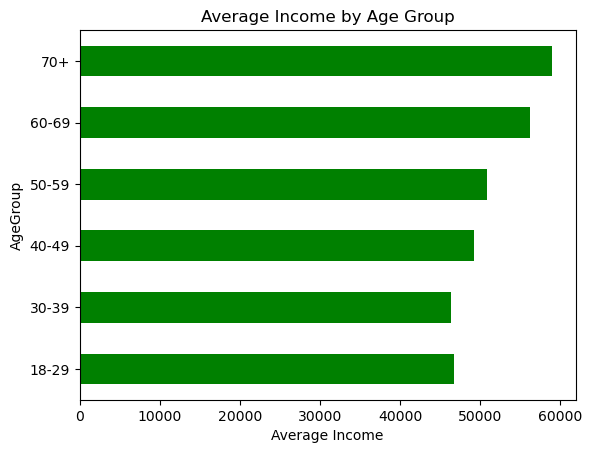

In [49]:
group3.plot(kind= "barh", color = "green")
plt.title("Average Income by Age Group")
plt.xlabel("Average Income")
plt.show()

In [50]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Age,TotalChildren,TotalSpendings,CustomerSince,AcceptedAny,AgeGroup
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,3,11,1,68,0,1617,5072,1,60-69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,3,11,0,71,2,27,4522,0,70+
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,3,11,0,60,0,776,4721,0,50-59
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,3,11,0,41,1,53,4548,0,40-49
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,3,11,0,44,1,422,4570,0,40-49


In [51]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'TotalChildren', 'TotalSpendings', 'CustomerSince',
       'AcceptedAny', 'AgeGroup'],
      dtype='object')

In [52]:
features = ["Age", "Income", "TotalSpendings", "NumWebPurchases", "NumStorePurchases", "NumWebVisitsMonth", "Recency"]

In [53]:
X = df[features].copy()

In [54]:
X

,Age,Income,TotalSpendings,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,68,58138.0,1617,8,4,7,58
1,71,46344.0,27,1,2,5,38
2,60,71613.0,776,8,10,4,26
3,41,26646.0,53,2,4,6,26
4,44,58293.0,422,5,6,5,94
...,...,...,...,...,...,...,...
2235,58,61223.0,1341,9,4,5,46
2236,79,64014.0,444,8,5,7,56
2237,44,56981.0,1241,2,13,6,91
2238,69,69245.0,843,6,10,3,8


In [55]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [56]:
X_scaled = scaler.fit_transform(X)

In [57]:
X_scaled

array([[ 0.98644293,  0.2340627 ,  1.67548812, ..., -0.55414289,
         0.69323197,  0.31053212],
       [ 1.23680074, -0.23455948, -0.96235832, ..., -1.16951781,
        -0.1315745 , -0.38050944],
       [ 0.31882209,  0.76947764,  0.28024985, ...,  1.29198186,
        -0.54397773, -0.79513438],
       ...,
       [-1.01641959,  0.18809052,  1.05169551, ...,  2.21504423,
         0.28082874,  1.4507507 ],
       [ 1.06989553,  0.67538765,  0.39140438, ...,  1.29198186,
        -0.95638097, -1.41707178],
       [ 1.23680074,  0.02470453, -0.7218    , ..., -0.55414289,
         0.69323197, -0.31140528]], shape=(2216, 7))

In [58]:
from sklearn.cluster import KMeans

In [59]:
wcss = []

In [60]:
for i in range(2,10):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [61]:
wcss

[10218.620143748785,
 9007.783808892227,
 8158.998459189668,
 7715.130178278553,
 7201.236919620858,
 6731.775292690292,
 6485.68572544352,
 5868.867898486858]

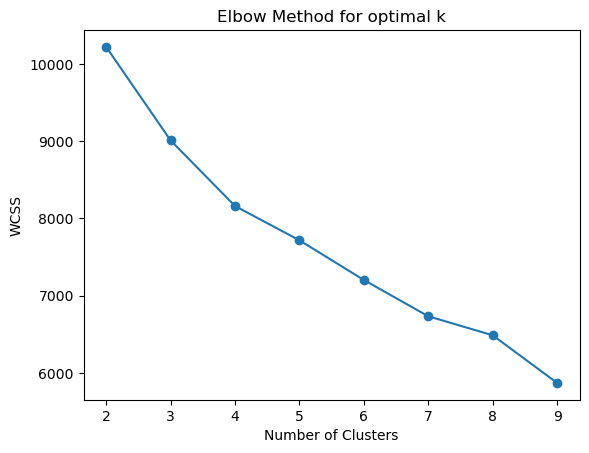

In [62]:
plt.plot(range(2,10),wcss,marker = "o")
plt.title("Elbow Method for optimal k")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [63]:
kmeans = KMeans(n_clusters = 6)
df["Clusters"] = kmeans.fit_predict(X_scaled)

In [64]:
df["Clusters"]

0       0
1       1
2       0
3       5
4       4
       ..
2235    0
2236    0
2237    3
2238    2
2239    1
Name: Clusters, Length: 2216, dtype: int32

In [65]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Z_CostContact,Z_Revenue,Response,Age,TotalChildren,TotalSpendings,CustomerSince,AcceptedAny,AgeGroup,Clusters
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,11,1,68,0,1617,5072,1,60-69,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,3,11,0,71,2,27,4522,0,70+,1
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,3,11,0,60,0,776,4721,0,50-59,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,3,11,0,41,1,53,4548,0,40-49,5
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,11,0,44,1,422,4570,0,40-49,4


In [66]:
cluster_summary = df.groupby("Clusters")[features].mean()

In [67]:
cluster_summary

,Age,Income,TotalSpendings,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Clusters,,,,,,,
0,59.394330,59628.298969,903.404639,8.108247,7.829897,6.507732,46.945876
1,69.687273,45506.374545,215.625455,2.730909,4.250909,5.363636,38.112727
2,53.327044,77998.952830,1259.723270,4.852201,8.735849,2.754717,23.965409
3,60.231638,73538.096045,1217.310734,4.553672,8.483051,2.765537,75.186441
4,51.914153,34726.549884,132.997680,2.424594,3.387471,6.682135,78.410673
5,48.066667,31836.844444,103.597778,2.124444,3.126667,6.782222,26.408889


In [68]:
df["Clusters"].value_counts()

Clusters
5    450
4    431
0    388
3    354
2    318
1    275
Name: count, dtype: int64

In [71]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)
df["PCA1"], df["PCA2"] = pca_data[:,0], pca_data[:,1]

In [72]:
pca_data

array([[ 1.1075188 , -0.21175951],
       [-1.33673385,  0.269839  ],
       [ 1.88227676, -1.01416098],
       ...,
       [ 1.1535966 ,  1.15056999],
       [ 1.88768024, -1.16073698],
       [-0.84182091, -0.15963623]], shape=(2216, 2))

In [73]:
df["PCA1"]

0       1.107519
1      -1.336734
2       1.882277
3      -1.784359
4       0.020363
          ...   
2235    1.248177
2236    0.508708
2237    1.153597
2238    1.887680
2239   -0.841821
Name: PCA1, Length: 2216, dtype: float64

In [74]:
df["PCA2"]

0      -0.211760
1       0.269839
2      -1.014161
3      -0.704928
4       1.235265
          ...   
2235   -0.535766
2236   -0.141328
2237    1.150570
2238   -1.160737
2239   -0.159636
Name: PCA2, Length: 2216, dtype: float64

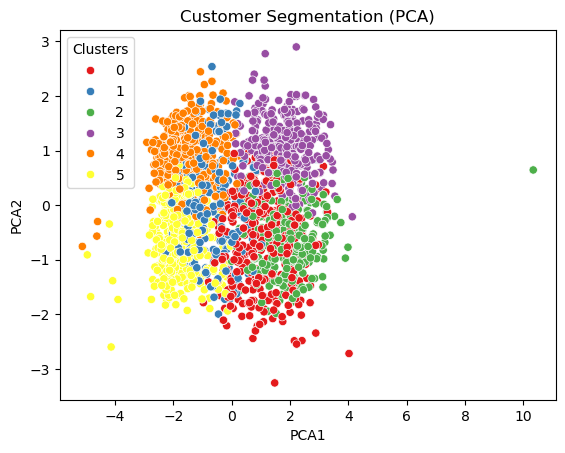

In [75]:
sns.scatterplot(x="PCA1", y="PCA2", hue = "Clusters", data = df, palette = "Set1")
plt.title("Customer Segmentation (PCA)")
plt.show()

In [76]:
cluster_summary

,Age,Income,TotalSpendings,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Clusters,,,,,,,
0,59.394330,59628.298969,903.404639,8.108247,7.829897,6.507732,46.945876
1,69.687273,45506.374545,215.625455,2.730909,4.250909,5.363636,38.112727
2,53.327044,77998.952830,1259.723270,4.852201,8.735849,2.754717,23.965409
3,60.231638,73538.096045,1217.310734,4.553672,8.483051,2.765537,75.186441
4,51.914153,34726.549884,132.997680,2.424594,3.387471,6.682135,78.410673
5,48.066667,31836.844444,103.597778,2.124444,3.126667,6.782222,26.408889


In [77]:
import joblib
joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']